Próbkowanie: 7 Stopień: 3
Błąd maksymalny = 45.27503875709257
Błąd średniokwadratowy = 0.5857042939352824


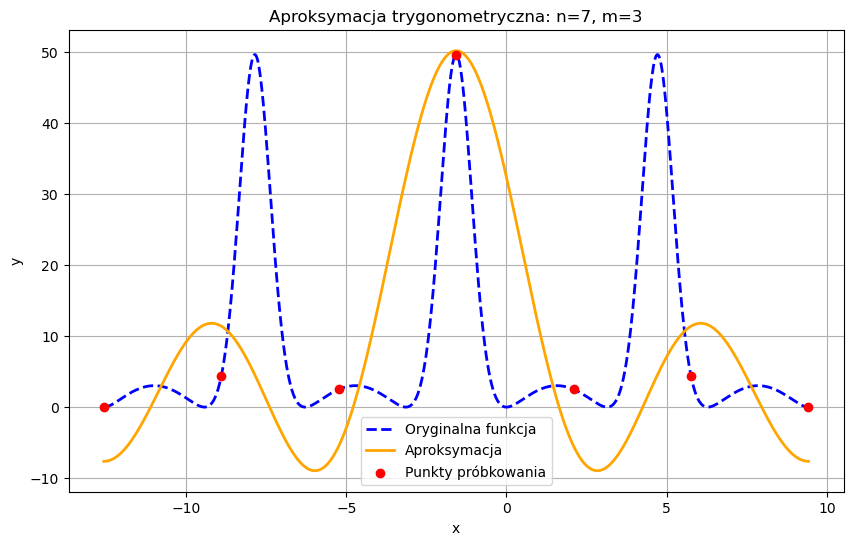

Próbkowanie: 8 Stopień: 3
Błąd maksymalny = 49.59788500781049
Błąd średniokwadratowy = 0.5368300897943588


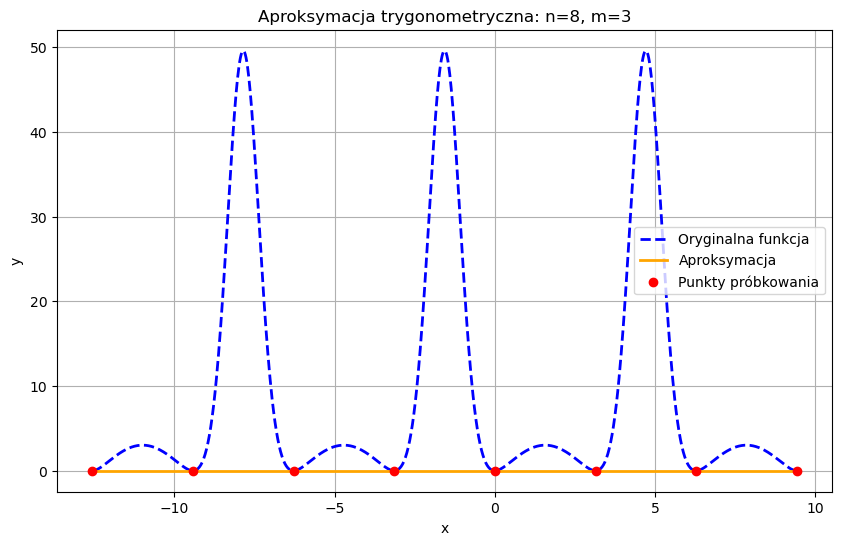

Próbkowanie: 9 Stopień: 3
Błąd maksymalny = 41.259889468279425
Błąd średniokwadratowy = 0.47252434571056556


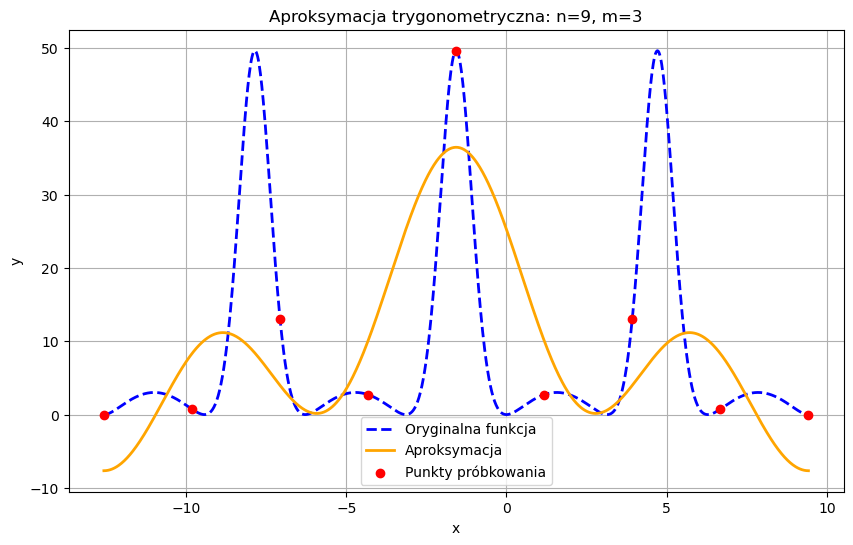

Próbkowanie: 9 Stopień: 4
Błąd maksymalny = 32.375883160909595
Błąd średniokwadratowy = 0.4388434758424404


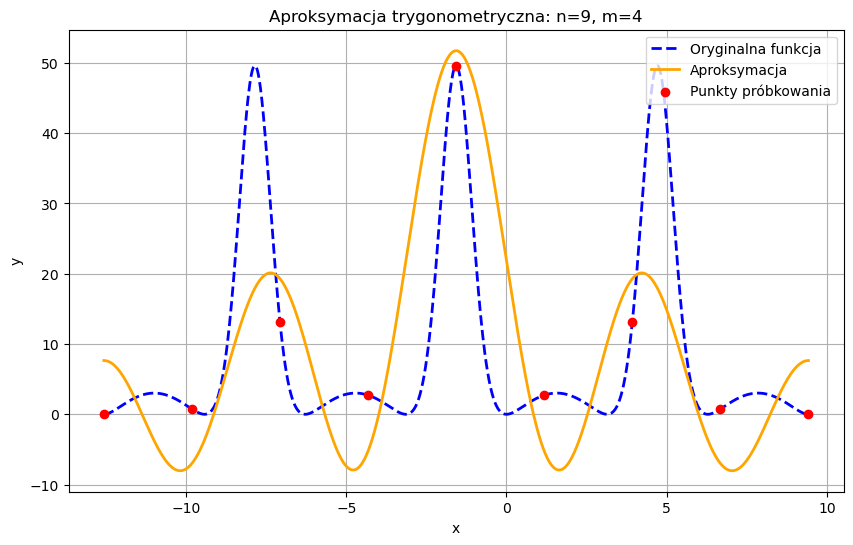

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def aproximated_function(x):
    return np.exp(-4 * np.sin(x)) + 4 * np.sin(x) - 1

def scale(x, a=-4*np.pi, b=3*np.pi):
    return (x - a) / (b - a) * (2 * np.pi) - np.pi

def plot_approximation(f, a, b, n, m):
    xi = np.linspace(a, b, n)
    yi = f(xi)
    
    n = len(xi)
    x_scaled = scale(xi)
    
    a0 = (2 / n) * np.sum(yi)
    ak = [(2 / n) * np.sum(yi * np.cos(k * x_scaled)) for k in range(1, m + 1)]
    bk = [(2 / n) * np.sum(yi * np.sin(k * x_scaled)) for k in range(1, m + 1)]
    
    def approx_func(x):
        x_scaled = scale(x)
        result = a0 / 2
        for k in range(1, m + 1):
            result += ak[k-1] * np.cos(k * x_scaled) + bk[k-1] * np.sin(k * x_scaled)
        return result

    x_plot = np.linspace(a, b, 1000)
    y_true = f(x_plot)
    y_approx = approx_func(x_plot)
    
    plt.figure(figsize=(10, 6))
    plt.plot(x_plot, y_true, '--', color='blue', label="Oryginalna funkcja", linewidth=2)
    plt.plot(x_plot, y_approx, '-', color='orange', label="Aproksymacja", linewidth=2)
    plt.scatter(xi, yi, color='red', label="Punkty próbkowania", zorder=5)
    plt.legend()
    plt.title(f"Aproksymacja trygonometryczna: n={n}, m={m}")
    plt.grid(True)
    plt.xlabel("x")
    plt.ylabel("y")

    mx = float("-inf")
    sr = 0
    print("Próbkowanie:", n, "Stopień:", m)
    for i in range(len(y_true)):
        mx = max(mx, abs(y_approx[i] - y_true[i]))
        sr += (y_true[i] - y_approx[i]) ** 2
    print("Błąd maksymalny =", mx)
    print("Błąd średniokwadratowy =", np.sqrt(sr) / len(y_true))

    plt.show()

for m in range(3,10): #małe wartości bo z takimi jak jest w pdfie rozmiar pliku był za duży
    for n in range(2*m + 1,10):
        if m <= (n - 1) // 2: 
            plot_approximation(aproximated_function, -4 * np.pi, 3 * np.pi, n, m)